##### 파이토치로 신경망 모델 만들기

In [1]:
# 파이토치 라이브러리 torchvision을 통해 패션 MNIST 데이터 가져오기
from torchvision.datasets import FashionMNIST

# root: 다운로드된 데이터를 저장할 위치 지정
# train: 훈련 데이터를 다운로드할지 테스트 데이터를 다운로드할지 결정 
fm_train = FashionMNIST(root='.', train=True, download=True)    # root='.' 현재 폴더에 클래스 이름과 동일한 폴더 생성)
fm_test = FashionMNIST(root='.', train=False, download=True)    # train=False 테스트 데이터 다운로드 

**텐서** 파이토치의 기본 데이터 구조

In [2]:
# 데이터 속성 확인
type(fm_train.data)

torch.Tensor

In [3]:
# 훈련 데이터와 테스트 데이터의 크기 확인 
print(fm_train.data.shape, fm_test.data.shape)

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


In [4]:
# 타깃 크기 확인
print(fm_train.targets.shape, fm_test.targets.shape)

torch.Size([60000]) torch.Size([10000])


→ 타깃이 1차원 배열이므로 원-핫 인코딩이 아니라 정숫값임

In [5]:
# 모델 훈련에 사용할 입력과 타깃 데이터 준비 
train_input = fm_train.data
train_target = fm_train.targets

In [6]:
# 입력 정규화
train_scaled = train_input / 255.0

In [7]:
# 훈련 세트와 검증 세트로 구분
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [8]:
# 훈련 세트와 검증 세트의 크기 확인
print(train_scaled.shape, val_scaled.shape)

torch.Size([48000, 28, 28]) torch.Size([12000, 28, 28])


In [9]:
# Sequential 클래스로 모델 생성
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 100),        # 케라스의 Dense층 역할, 입력 크기와 출력 크기(뉴런 개수)를 매개변수로 전달
    nn.ReLU(),                  # 활성화 함수를 별도의 층으로 추가
    nn.Linear(100, 10)          # 출력층
)                               # 활성화 함수 없음

# 파이토치에서는 모델의 입력 크기를 사전에 지정할 필요가 없기 때문에 Input()과 같은 별도의 입력 정의 함수가 없음 

In [10]:
# torchinfo 패키지: 케라스의 summart() 메서드와 같이 전체 구조를 확인 
from torchinfo import summary

summary(model, input_size=(32, 28, 28))     # 한 번에 32개의 샘플이 모델에 입력되는 형태 

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 10]                  --
├─Flatten: 1-1                           [32, 784]                 --
├─Linear: 1-2                            [32, 100]                 78,500
├─ReLU: 1-3                              [32, 100]                 --
├─Linear: 1-4                            [32, 10]                  1,010
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
Total mult-adds (M): 2.54
Input size (MB): 0.10
Forward/backward pass size (MB): 0.03
Params size (MB): 0.32
Estimated Total Size (MB): 0.45

In [11]:
import torch 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")       # GPU가 있는 경우 True, 없을 경우 False 반환
model.to(device)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=10, bias=True)
)

In [12]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())      # 훈련 가능한 모든 파라미터 전달

**파이토치 모델 훈련 구조**

```python 
for 에포크 반복
    에포크 손실 초기화
    for 배치 반복
        배치 입력과 타깃 준비
        옵티마이저 그레디언트 초기화
        모델에 입력 전달
        모델 출력과 타깃으로 손실 계산
        손실 역전파
        모델 파라미터 업데이트
        에포크 손실 기록
    에포크 손실 출력

**정방향 계산(forward pass) / 순전파(forward propagation)** 

입력층 → 은닉층 → 출력층 순으로 신호가 한 방향으로 흘러가는 계산 과정

모델이 계산한 출력과 타깃을 손실 함수에 전달하여 손실을 계산

**역전파(backpropagation)** 

계산한 손실을 모델의 출력층에서부터 입력층 방향으로 거꾸로 전달하여 각 층의모델 파라미터에 대한 그레이디언트 계산 

옵티마이저 객체는 계산된 그레이디언트를 사용해 손실 함수가 감소되는 방향으로 모델 파라미터를 업데이트 

In [13]:
epochs = 5
batches = int(len(train_scaled)/32)
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for i in range(batches):
        inputs = train_scaled[i*32:(i+1)*32].to(device)
        targets = train_target[i*32:(i+1)*32].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"에포크:{epoch + 1}, 손실:{train_loss/batches:.4f}")

에포크:1, 손실:0.5502
에포크:2, 손실:0.4064
에포크:3, 손실:0.3645
에포크:4, 손실:0.3378
에포크:5, 손실:0.3180


In [14]:
# 검증 세트 사용해서 모델 성능 평가 
model.eval()
with torch.no_grad():                       # 그레이디언트 계산 안함, 메모리와 계산량이 줄어듬
    val_scaled = val_scaled.to(device)
    val_target = val_target.to(device)
    outputs = model(val_scaled)             # 검증 세트의 샘플 12000개에 대해 타깃 클래스마다 출력
    predicts = torch.argmax(outputs, 1)     # 두 번째 축을 따라 가장 큰 값의 인덱스를 predicts에 저장
    corrects = (predicts == val_target).sum().item()

accuracy = corrects / len(val_target)
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.8748


---

##### 파이토치로 신경망 모델 훈련하기

In [15]:
# 데이터 로드하고 훈련 세트와 검증 세트 준비 
from torchvision.datasets import FashionMNIST

fm_train = FashionMNIST(root='.', train=True, download=True)
fm_test = FashionMNIST(root='.', train=False, download=True)

train_input = fm_train.data
train_target = fm_train.targets
train_scaled = train_input / 255.0

from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [16]:
# 두 개의 밀집층 사이에 드롭아웃 추가 
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 100),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(100, 10)
)

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")       # GPU에 적재
model.to(device)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=100, out_features=10, bias=True)
)

In [17]:
# 손실 함수와 옵티마이저 준비 
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [18]:
# 필요한 변수 준비 
train_hist = []     # 훈련 손실
val_hist = []       # 검증 손실
patience = 2        # 검증 손실이 향상될 때까지의 에포크 횟수 설정
best_loss = -1      # 최상의 손실 기록
early_stopping_counter = 0      # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 기록

In [19]:
epochs = 20
batches = int(len(train_scaled)/32)
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for i in range(batches):
        inputs = train_scaled[i*32:(i+1)*32].to(device)
        targets = train_target[i*32:(i+1)*32].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    model.eval()                        # 검증 세트에 대한 손실 계산 (!들여쓰기 유의)
    val_loss = 0
    with torch.no_grad():
        val_scaled = val_scaled.to(device)
        val_target = val_target.to(device)
        outputs = model(val_scaled)
        loss = criterion(outputs, val_target)
        val_loss = loss.item()

    train_hist.append(train_loss/batches)       # 훈련 손실과 검증 손실을 기록
    val_hist.append(val_loss)
    print(f"에포크:{epoch+1},",
          f"훈련 손실:{train_loss/batches:.4f}, 검증 손실:{val_loss:.4f}")

    if best_loss == -1 or val_loss < best_loss:         # 첫 번째 에포크이거나 검증 손실이 이전에 기록된 최상의 손실보다 적으면
        best_loss = val_loss                            # 현재 검증 손실을 최상의 손실로 저장
        early_stopping_counter = 0                      # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 기록
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크:1, 훈련 손실:0.6107, 검증 손실:0.4345
에포크:2, 훈련 손실:0.4483, 검증 손실:0.3925
에포크:3, 훈련 손실:0.4082, 검증 손실:0.3741
에포크:4, 훈련 손실:0.3885, 검증 손실:0.3691
에포크:5, 훈련 손실:0.3710, 검증 손실:0.3515
에포크:6, 훈련 손실:0.3591, 검증 손실:0.3422
에포크:7, 훈련 손실:0.3492, 검증 손실:0.3377
에포크:8, 훈련 손실:0.3397, 검증 손실:0.3325
에포크:9, 훈련 손실:0.3315, 검증 손실:0.3255
에포크:10, 훈련 손실:0.3242, 검증 손실:0.3335
에포크:11, 훈련 손실:0.3172, 검증 손실:0.3282
11번째 에포크에서 조기 종료되었습니다.


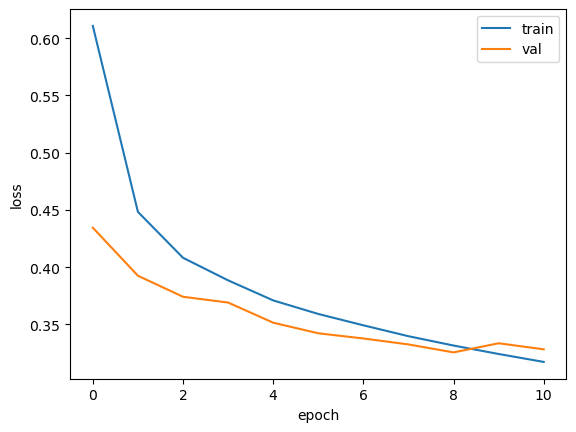

In [20]:
# 훈련 손실과 검증 손실 그래프 그리기 
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

9번째 에포크에서 검증 점수가 가장 좋고 그 이후에 과대적합되어 11번째 에포크에서 멈춘 것을 확인 가능

In [21]:
# 최상의 파라미터로 model 객체 업데이트 
model.load_state_dict(torch.load('best_model.pt', weights_only=True))

<All keys matched successfully>

In [22]:
# 최상의 모델을 사용해 검증 세트에 대한 성능 확인
model.eval()
with torch.no_grad():
    val_scaled = val_scaled.to(device)
    val_target = val_target.to(device)
    outputs = model(val_scaled)
    predicts = torch.argmax(outputs, 1)
    corrects = (predicts == val_target).sum().item()

accuracy = corrects / len(val_target)
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.8834
